<a href="https://colab.research.google.com/github/krishn12323/aiml_lab/blob/main/Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df=pd.read_csv(url)

#first few records
print(df.head())

#no of rows n columns
print("Shape:",df.shape)

#col names
print("\nColumns:")
print(df.columns.tolist())

#data types
print("\nData Types:")
print(df.dtypes)

#Statistical summary
print("\nStatisticl Summary:")
print(df.describe())

#Categorical cols
print("\nCategorical Columns:")
print(df.select_dtypes(include='object').columns.tolist())

#Numerical cols
print("\nNumerical columns:")
print(df.select_dtypes(include=np.number).columns.tolist())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Sh

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
             Missing Count  Missing Percentage
PassengerId              0            0.000000
Survived                 0            0.000000
Pclass                   0            0.000000
Name                     0            0.000000
Sex                      0            0.000000
Age                    177           19.865320
SibSp                    0            0.000000
Parch                    0            0.000000
Ticket                   0            0.000000
Fare                     0            0.000000
Cabin                  687           77.104377
Embarked                 2            0.224467


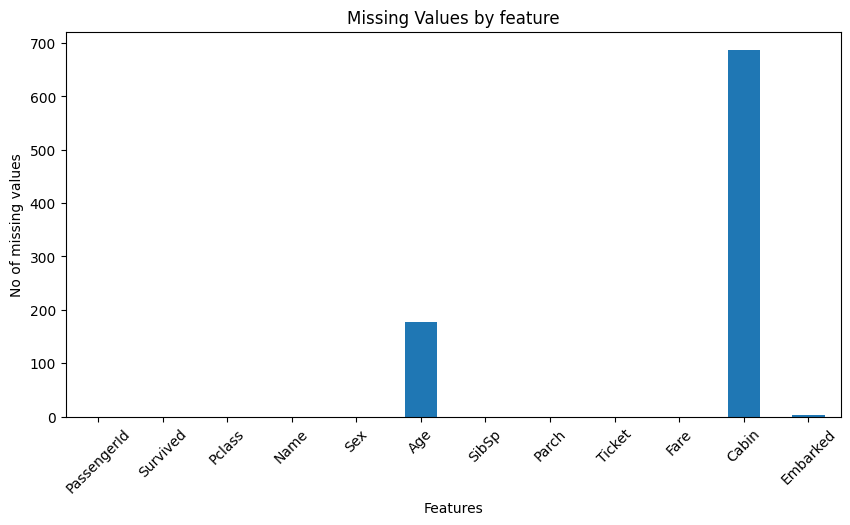

duplicate rows: 0


In [11]:
missing=df.isnull().sum()

print(missing)

missing_percent=df.isnull().sum()/len(df) *100

missing_table=pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percent
})

print(missing_table)

plt.figure(figsize=(10,5))
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values by feature")
plt.xlabel("Features")
plt.ylabel("No of missing values")
plt.xticks(rotation=45)
plt.show()

print("duplicate rows:",df.duplicated().sum())

In [14]:
#Replace missing vals by mean
df_mean=df.copy()

mean_age=df_mean['Age'].mean()
df_mean['Age']=df_mean['Age'].fillna(mean_age)

print("Remaining missing values:",
      df_mean['Age'].isnull().sum())

#Replace missing vals by medians
df_median=df.copy()

median_age=df_median['Age'].median()

df_median['Age']=df_median['Age'].fillna(median_age)

print("Remaining missing Age values:",
      df_median['Age'].isnull().sum())

print("Mean Age:",df['Age'].mean())
print("Median Age:",df['Age'].median())

df_mode=df.copy()

mode_embarked=df_mode['Embarked'].mode()[0]

df_mode['Embarked']=df_mode['Embarked'].fillna(mode_embarked)

print("Remaining missing Embarked values:",
      df_mode['Embarked'].isnull().sum())




Remaining missing values: 0
Remaining missing Age values: 0
Mean Age: 29.69911764705882
Median Age: 28.0
Remaining missing Embarked values: 0


In [23]:
#Encoding - One-Hot
print(df[['Sex','Embarked']].head(10))
from sklearn.preprocessing import OneHotEncoder

encoder=OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)
encoded=encoder.fit_transform(df[['Sex','Embarked']])

encoded_df=pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Sex','Embarked'])


)

print(encoded_df.head())

#Encoding-Label
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

df['Survived_encoded']=le.fit_transform(df['Survived'])

print(df[['Survived','Survived_encoded']].head())


      Sex Embarked
0    male        S
1  female        C
2  female        S
3  female        S
4    male        S
5    male        Q
6    male        S
7    male        S
8  female        S
9  female        C
   Sex_female  Sex_male  Embarked_C  Embarked_Q  Embarked_S  Embarked_nan
0         0.0       1.0         0.0         0.0         1.0           0.0
1         1.0       0.0         1.0         0.0         0.0           0.0
2         1.0       0.0         0.0         0.0         1.0           0.0
3         1.0       0.0         0.0         0.0         1.0           0.0
4         0.0       1.0         0.0         0.0         1.0           0.0
   Survived  Survived_encoded
0         0                 0
1         1                 1
2         1                 1
3         1                 1
4         0                 0
